# 06. Comparison and ensemble — from checkpoints

Drop-in replacement for `06_comparison_and_ensemble_1.ipynb` that does **not** require the per-model `test_probs.npz` or `results.json` files. It discovers every `.keras` checkpoint in `saved_models/`, runs inference on `dataset_split/test/`, and computes every metric the original notebook did (Top-1/3/5, macro-F1, weighted-F1, confusion matrix, ensembles, agreement analysis).

Assumptions baked in:
- Every checkpoint has preprocessing **inside** the model (a `Rescaling(1/255)` layer or `include_preprocessing=True` on the backbone), so we feed raw images in the `[0, 255]` range. For checkpoints that expect `/255` inputs, flip their entry in `PREPROCESS_OVERRIDES`.
- `model.input_shape` tells us the expected `(H, W)` — the test dataset is rebuilt once per unique resolution, always with `shuffle=False`, so sample order is identical across models (required for ensembling).

Cached softmaxes land in `outputs/comparison_from_ckpts/<stem>/test_probs.npz` so reruns are instant and the original `outputs/<model>/` directories are never touched.

**Pre-cached probs (2026-04-24):** 6 of 10 models already have cached test_probs.npz under outputs/comparison_from_ckpts/<stem>/. Weighted AlexNet excluded per request. Fresh inference only runs for: 03_functional_efficientnet_best.keras (phase 1), phase1_best_convnextiny.keras, phase2_best_convnextiny.keras.

## 0. Imports and paths

Resolves the project root automatically whether the Jupyter server was started in `notebooks/` or at the project root. Override with env var `DL_PROJECT_ROOT` or by hard-coding `PROJECT_ROOT` below.

In [11]:
import os, json, glob, time, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
import keras
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, f1_score, classification_report,
)

def _find_project_root():
    env = os.environ.get("DL_PROJECT_ROOT")
    if env and os.path.isdir(env):
        return os.path.abspath(env)
    cwd = os.path.abspath(os.getcwd())
    for _ in range(5):
        if os.path.isdir(os.path.join(cwd, "dataset_split", "train")) and \
           os.path.isdir(os.path.join(cwd, "saved_models")):
            return cwd
        cwd = os.path.dirname(cwd)
    return os.path.abspath(os.path.join(os.getcwd(), ".."))

PROJECT_ROOT = _find_project_root()
# If auto-detection fails, uncomment and edit:
# PROJECT_ROOT = r"C:\Users\pedro\Documentos\NOVA IMS\2º semestre- eu\Deep Learning\Deep_Learning_project"

SPLIT_DIR   = os.path.join(PROJECT_ROOT, "dataset_split")
TEST_DIR    = os.path.join(SPLIT_DIR, "test")
SAVED_DIR   = os.path.join(PROJECT_ROOT, "saved_models")
OUT_DIR     = os.path.join(PROJECT_ROOT, "outputs", "comparison_from_ckpts")
BATCH_SIZE  = 32

os.makedirs(OUT_DIR, exist_ok=True)

CLASS_NAMES = sorted(os.listdir(os.path.join(SPLIT_DIR, "train")))
N_CLASSES   = len(CLASS_NAMES)
print(f"CWD          = {os.getcwd()}")
print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"SAVED_DIR    = {SAVED_DIR}  (exists={os.path.isdir(SAVED_DIR)})")
print(f"TEST_DIR     = {TEST_DIR}  (exists={os.path.isdir(TEST_DIR)})")
print(f"OUT_DIR      = {OUT_DIR}")
print(f"{N_CLASSES} classes")


CWD          = c:\Users\pedro\Documentos\NOVA IMS\2º semestre- eu\Deep Learning\Deep_Learning_project\notebooks
PROJECT_ROOT = c:\Users\pedro\Documentos\NOVA IMS\2º semestre- eu\Deep Learning\Deep_Learning_project
SAVED_DIR    = c:\Users\pedro\Documentos\NOVA IMS\2º semestre- eu\Deep Learning\Deep_Learning_project\saved_models  (exists=True)
TEST_DIR     = c:\Users\pedro\Documentos\NOVA IMS\2º semestre- eu\Deep Learning\Deep_Learning_project\dataset_split\test  (exists=True)
OUT_DIR      = c:\Users\pedro\Documentos\NOVA IMS\2º semestre- eu\Deep Learning\Deep_Learning_project\outputs\comparison_from_ckpts
23 classes


## 1. Discover every `.keras` checkpoint

Lists the raw contents of `saved_models/` first (so you can confirm nothing is hiding). Then globs `*.keras` and maps each filename to a pretty display name + family via `REGISTRY`. Any `.keras` file not in `REGISTRY` is still picked up but with `family="unknown"` — it won't be part of the family-conditional ensembles but it *is* part of the `All` ensemble and all per-model metrics.

In [12]:
REGISTRY = {
    "sequential_model_1_best.keras":                      ("Sequential baseline",            "scratch",  "sequential"),
    "sequential_model_1_best_randaug_experiment.keras":   ("Sequential + RandAug",           "scratch",  "sequential"),
    "04_oop_miniresnet_best.keras":                       ("MiniResNet (OOP)",               "scratch",  "subclassing"),
    "alex_net_inspired.keras":                            ("AlexNet-inspired",               "scratch",  "functional"),
    # "alex_net_insipred_weighted.keras":                 ("AlexNet-inspired (weighted)",    "scratch",  "functional"),  # excluded 2026-04-24
    "03_functional_efficientnet_best.keras":              ("EfficientNetV2-B0 (phase 1)",    "transfer", "functional"),
    "03_functional_efficientnet_phase2_best.keras":       ("EfficientNetV2-B0 (phase 2)",    "transfer", "functional"),
    "05_functional_resnet50v2_phase2_best.keras":     ("ResNet50V2 (phase 2)",           "transfer", "functional"),
    "phase1_best_convnextiny.keras":                      ("ConvNeXt-Tiny (phase 1)",        "transfer", "functional"),
    "phase2_best_convnextiny.keras":                      ("ConvNeXt-Tiny (phase 2)",        "transfer", "functional"),
}

PREPROCESS_OVERRIDES = {
    # "alex_net_inspired.keras": "div255",   # uncomment if the model lacks internal Rescaling
}

if not os.path.isdir(SAVED_DIR):
    raise FileNotFoundError(
        f"SAVED_DIR does not exist: {SAVED_DIR}\n"
        f"CWD is {os.getcwd()}. Hard-code PROJECT_ROOT in the previous cell."
    )

all_entries = sorted(os.listdir(SAVED_DIR))
print(f"Raw listing of {SAVED_DIR}  ({len(all_entries)} entries):")
for e in all_entries:
    full = os.path.join(SAVED_DIR, e)
    if os.path.isfile(full):
        tag = "keras" if e.endswith(".keras") else "other"
        size_mb = os.path.getsize(full) / 1e6
        print(f"  [{tag:5s}] {e}  ({size_mb:.1f} MB)")
    else:
        print(f"  [dir  ] {e}")

ckpt_files = sorted(glob.glob(os.path.join(SAVED_DIR, "*.keras")))
print(f"\n.keras files picked up by glob: {len(ckpt_files)}")
for p in ckpt_files:
    name = os.path.basename(p)
    pretty, fam, api = REGISTRY.get(name, (name.replace(".keras", ""), "unknown", "unknown"))
    marker = "" if name in REGISTRY else "   <- not in REGISTRY"
    print(f"  {name:55s} -> {pretty}  [{fam}/{api}]{marker}")


Raw listing of c:\Users\pedro\Documentos\NOVA IMS\2º semestre- eu\Deep Learning\Deep_Learning_project\saved_models  (9 entries):
  [keras] 03_functional_efficientnet_best.keras  (51.2 MB)
  [keras] 03_functional_efficientnet_phase2_best.keras  (54.0 MB)
  [keras] 04_oop_miniresnet_best.keras  (33.4 MB)
  [keras] 05_functional_resnet50v2_phase2_best.keras  (181.9 MB)
  [keras] alex_net_inspired.keras  (4.1 MB)
  [keras] phase1_best_convnextiny.keras  (114.0 MB)
  [keras] phase2_best_convnextiny.keras  (112.4 MB)
  [keras] sequential_model_1_best.keras  (58.6 MB)
  [keras] sequential_model_1_best_randaug_experiment.keras  (58.6 MB)

.keras files picked up by glob: 9
  03_functional_efficientnet_best.keras                   -> EfficientNetV2-B0 (phase 1)  [transfer/functional]
  03_functional_efficientnet_phase2_best.keras            -> EfficientNetV2-B0 (phase 2)  [transfer/functional]
  04_oop_miniresnet_best.keras                            -> MiniResNet (OOP)  [scratch/subclassing]
  

The files from ConvNeXTiny were not possible to load since the tensorflow version was incompatible with the registry

## 2. Build a test dataset per resolution (cached)

One `tf.data.Dataset` per distinct `(H, W)` — built with `shuffle=False` and `label_mode='int'`, so every model iterates the test set in the identical order (required for ensembling and agreement analysis).

In [13]:
_DS_CACHE = {}

def get_test_ds(img_size):
    """Return a cached test tf.data.Dataset at the requested (H, W). shuffle=False always."""
    key = tuple(img_size)
    if key in _DS_CACHE:
        return _DS_CACHE[key]
    ds = keras.utils.image_dataset_from_directory(
        TEST_DIR,
        labels="inferred",
        label_mode="int",
        class_names=CLASS_NAMES,
        color_mode="rgb",
        batch_size=BATCH_SIZE,
        image_size=key,
        shuffle=False,
        interpolation="bilinear",
    )
    ds = ds.prefetch(tf.data.AUTOTUNE)
    _DS_CACHE[key] = ds
    return ds


def infer_input_size(model, default=(224, 224)):
    """Extract (H, W) from model.input_shape; fall back to default if dynamic."""
    shape = model.input_shape
    if isinstance(shape, list):
        shape = shape[0]
    h, w = shape[1], shape[2]
    if h is None or w is None:
        return default
    return (int(h), int(w))


## 3. Predict on the test set for every checkpoint

For each checkpoint: load the model, introspect its expected `(H, W)`, grab the matching cached test dataset, run `model.predict`, and persist softmaxes to `outputs/comparison_from_ckpts/<stem>/test_probs.npz`. If that file already exists, we skip inference and reuse it. Failures are caught and logged so a broken checkpoint doesn't abort the whole run.

Memory hygiene: after each model we `del` it, `clear_session()`, and `gc.collect()` so the kernel stays flat across 10 checkpoints.

In [14]:
def preprocess_batch(x, mode):
    if mode == "div255":
        return tf.cast(x, tf.float32) / 255.0
    return tf.cast(x, tf.float32)   # default: feed raw 0..255


def predict_checkpoint(ckpt_path, mode="raw"):
    """Load a .keras checkpoint, predict on the appropriately-sized test set.

    Returns (probs (N, C), y_true (N,), input_size, n_params, elapsed_seconds).
    """
    t0 = time.time()
    model = keras.models.load_model(ckpt_path, compile=False, safe_mode=False)
    img_size = infer_input_size(model)
    n_params = int(model.count_params())

    ds = get_test_ds(img_size)
    probs_list, y_list = [], []
    for xb, yb in ds:
        xb = preprocess_batch(xb, mode)
        pb = model.predict(xb, verbose=0)
        probs_list.append(pb)
        y_list.append(yb.numpy())

    probs  = np.concatenate(probs_list, axis=0).astype(np.float32)
    y_true = np.concatenate(y_list, axis=0).astype(np.int64)

    del model
    keras.backend.clear_session()
    gc.collect()
    return probs, y_true, img_size, n_params, time.time() - t0


# Choose which checkpoints to evaluate. By default: everything discovered.
SELECTED = [os.path.basename(p) for p in ckpt_files]
# SELECTED = ["03_functional_efficientnet_best.keras", "phase1_best_convnextiny.keras"]

loaded = {}
for ckpt_name in SELECTED:
    ckpt_path = os.path.join(SAVED_DIR, ckpt_name)
    if not os.path.exists(ckpt_path):
        print(f"[skip]   {ckpt_name}: file not found")
        continue
    pretty, fam, api = REGISTRY.get(ckpt_name, (ckpt_name.replace(".keras", ""), "unknown", "unknown"))
    stem = os.path.splitext(ckpt_name)[0]
    cache_dir = os.path.join(OUT_DIR, stem)
    os.makedirs(cache_dir, exist_ok=True)
    cache_path = os.path.join(cache_dir, "test_probs.npz")
    meta_path  = os.path.join(cache_dir, "meta.json")

    if os.path.exists(cache_path) and os.path.exists(meta_path):
        with np.load(cache_path) as z:
            probs, y_true = z["probs"], z["y_true"]
        with open(meta_path) as f:
            meta = json.load(f)
        img_size = tuple(meta["img_size"])
        n_params = int(meta["n_params"])
        print(f"[cache]  {pretty:35s} probs={probs.shape} input={img_size} params={n_params/1e6:.2f}M")
    else:
        mode = PREPROCESS_OVERRIDES.get(ckpt_name, "raw")
        print(f"[infer]  {pretty:35s} preprocessing={mode} ... ", end="", flush=True)
        try:
            probs, y_true, img_size, n_params, elapsed = predict_checkpoint(ckpt_path, mode=mode)
        except Exception as e:
            print(f"FAILED: {type(e).__name__}: {e}")
            continue
        np.savez_compressed(cache_path, probs=probs, y_true=y_true)
        with open(meta_path, "w") as f:
            json.dump({"img_size": list(img_size), "n_params": n_params,
                       "ckpt": ckpt_name, "family": fam, "api": api, "preprocess": mode}, f, indent=2)
        print(f"done  probs={probs.shape} input={img_size} params={n_params/1e6:.2f}M  ({elapsed:.1f}s)")

    loaded[pretty] = {
        "probs": probs, "y_true": y_true,
        "img_size": img_size, "n_params": n_params,
        "ckpt": ckpt_name, "family": fam, "api": api,
    }

print(f"\nLoaded {len(loaded)} models: {list(loaded.keys())}")


[infer]  EfficientNetV2-B0 (phase 1)         preprocessing=raw ... FAILED: TypeError: <class 'keras.src.models.functional.Functional'> could not be deserialized properly. Please ensure that components that are Python object instances (layers, models, etc.) returned by `get_config()` are explicitly deserialized in the model's `from_config()` method.

config={'module': 'keras.src.models.functional', 'class_name': 'Functional', 'config': {}, 'registered_name': 'Functional', 'build_config': {'input_shape': None}, 'compile_config': None}.

Exception encountered: <class 'keras.src.models.sequential.Sequential'> could not be deserialized properly. Please ensure that components that are Python object instances (layers, models, etc.) returned by `get_config()` are explicitly deserialized in the model's `from_config()` method.

config={'module': 'keras', 'class_name': 'Sequential', 'config': {'name': 'augmentation', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'co

## 4. Per-model metrics

Compute Top-1/3/5 and macro/weighted F1 from the cached probabilities. Written to `outputs/comparison_from_ckpts/comparison_table.csv`.

In [15]:
def per_model_metrics(probs, y_true):
    y_pred = np.argmax(probs, axis=1)
    top1 = float(np.mean(y_true == y_pred))
    top3 = float(np.mean([y_true[i] in np.argsort(probs[i])[-3:] for i in range(len(y_true))]))
    top5 = float(np.mean([y_true[i] in np.argsort(probs[i])[-5:] for i in range(len(y_true))]))
    return {
        "top1": top1, "top3": top3, "top5": top5,
        "macro_f1":    float(f1_score(y_true, y_pred, average="macro",    zero_division=0)),
        "weighted_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
        "y_pred":      y_pred,
    }

for name, d in loaded.items():
    d.update(per_model_metrics(d["probs"], d["y_true"]))

rows = []
for name, d in loaded.items():
    rows.append({
        "Model":       name,
        "Family":      d["family"],
        "API":         d["api"],
        "Input":       f"{d['img_size'][0]}x{d['img_size'][1]}",
        "Params (M)":  f"{d['n_params'] / 1e6:.2f}",
        "Top-1":       f"{d['top1']:.4f}",
        "Top-3":       f"{d['top3']:.4f}",
        "Top-5":       f"{d['top5']:.4f}",
        "Macro-F1":    f"{d['macro_f1']:.4f}",
        "Weighted-F1": f"{d['weighted_f1']:.4f}",
    })
df = pd.DataFrame(rows).sort_values("Top-1", ascending=False).reset_index(drop=True)
df.to_csv(os.path.join(OUT_DIR, "comparison_table.csv"), index=False)
df


,Model,Family,API,Input,Params (M),Top-1,Top-3,Top-5,Macro-F1,Weighted-F1
0,EfficientNetV2-B0 (phase 2),transfer,functional,224x224,6.09,0.7811,0.9045,0.9440,0.7549,0.7767
1,ResNet50V2 (phase 2),transfer,functional,224x224,23.63,0.7186,0.8961,0.9405,0.7041,0.7215
2,AlexNet-inspired,scratch,functional,128x128,0.34,0.4858,0.7116,0.8061,0.4401,0.4718
3,MiniResNet (OOP),scratch,subclassing,160x160,2.77,0.4833,0.7116,0.8236,0.4750,0.4902
4,Sequential baseline,scratch,sequential,128x128,4.88,0.3433,0.6007,0.7226,0.3026,0.3361
5,Sequential + RandAug,scratch,sequential,128x128,4.88,0.3398,0.5702,0.6922,0.2376,0.2884


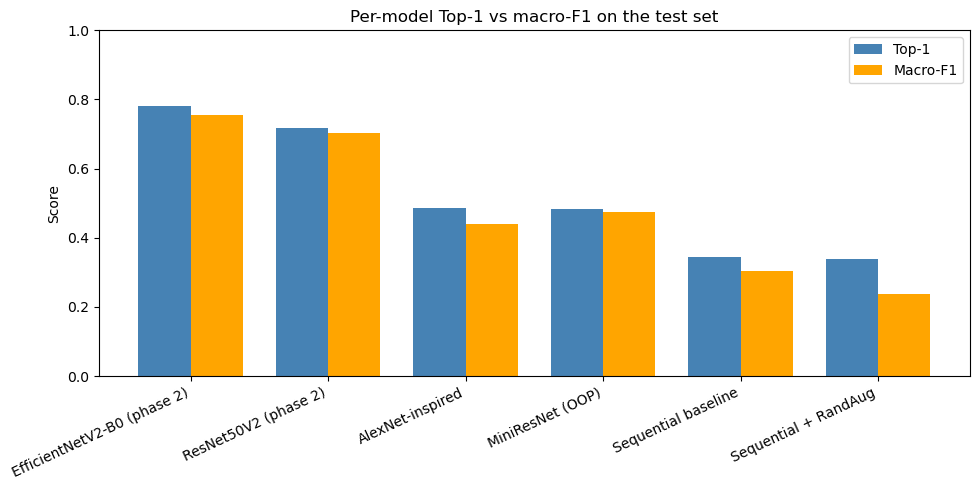

In [16]:
# Per-model bar chart: Top-1 vs Macro-F1.
fig, ax = plt.subplots(figsize=(max(10, 0.9 * len(df)), 5))
x = np.arange(len(df))
w = 0.38
ax.bar(x - w/2, df["Top-1"].astype(float).values,    w, label="Top-1",    color="steelblue")
ax.bar(x + w/2, df["Macro-F1"].astype(float).values, w, label="Macro-F1", color="orange")
ax.set_xticks(x)
ax.set_xticklabels(df["Model"].values, rotation=25, ha="right")
ax.set_ylabel("Score")
ax.set_title("Per-model Top-1 vs macro-F1 on the test set")
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "per_model_scores.png"), dpi=150, bbox_inches="tight")
plt.show()


## 5. Probability-averaging ensembles

Four variants:
- `All` — every loaded model.
- `Transfer only` — family == `transfer`.
- `Scratch only` — family == `scratch`.
- `Best per family` — pick the single strongest (by macro-F1) from each family, then average. Usually the cleanest comparison because it drops redundant same-architecture checkpoints.

In [17]:
def ensemble_metrics(probs_list, y_true):
    probs  = np.mean(probs_list, axis=0)
    y_pred = np.argmax(probs, axis=1)
    top1 = float(np.mean(y_true == y_pred))
    top3 = float(np.mean([y_true[i] in np.argsort(probs[i])[-3:] for i in range(len(y_true))]))
    top5 = float(np.mean([y_true[i] in np.argsort(probs[i])[-5:] for i in range(len(y_true))]))
    return {
        "top1": top1, "top3": top3, "top5": top5,
        "macro_f1":    float(f1_score(y_true, y_pred, average="macro",    zero_division=0)),
        "weighted_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
        "probs": probs, "y_pred": y_pred,
    }

names  = list(loaded.keys())
y_true = next(iter(loaded.values()))["y_true"]
for n in names:
    assert np.array_equal(loaded[n]["y_true"], y_true), f"y_true mismatch for {n} -- test-set ordering diverged"

ensembles = {}
ensembles["All"] = ensemble_metrics([loaded[n]["probs"] for n in names], y_true)

transfer = [n for n in names if loaded[n]["family"] == "transfer"]
scratch  = [n for n in names if loaded[n]["family"] == "scratch"]
if len(transfer) >= 2:
    ensembles["Transfer only"] = ensemble_metrics([loaded[n]["probs"] for n in transfer], y_true)
if len(scratch) >= 2:
    ensembles["Scratch only"]  = ensemble_metrics([loaded[n]["probs"] for n in scratch],  y_true)

family_best = {}
for n in names:
    fam = loaded[n]["family"]
    if fam == "unknown":
        continue
    if fam not in family_best or loaded[n]["macro_f1"] > loaded[family_best[fam]]["macro_f1"]:
        family_best[fam] = n
if len(family_best) >= 2:
    picked = list(family_best.values())
    ensembles[f"Best per family ({', '.join(picked)})"] = ensemble_metrics(
        [loaded[n]["probs"] for n in picked], y_true)

ens_rows = []
for name, d in loaded.items():
    ens_rows.append({
        "Config": name,
        "Top-1": f"{d['top1']:.4f}", "Top-3": f"{d['top3']:.4f}", "Top-5": f"{d['top5']:.4f}",
        "Macro-F1": f"{d['macro_f1']:.4f}", "Weighted-F1": f"{d['weighted_f1']:.4f}",
    })
for name, e in ensembles.items():
    ens_rows.append({
        "Config": f"Ensemble ({name})",
        "Top-1": f"{e['top1']:.4f}", "Top-3": f"{e['top3']:.4f}", "Top-5": f"{e['top5']:.4f}",
        "Macro-F1": f"{e['macro_f1']:.4f}", "Weighted-F1": f"{e['weighted_f1']:.4f}",
    })
ens_df = pd.DataFrame(ens_rows)
ens_df.to_csv(os.path.join(OUT_DIR, "ensemble_comparison.csv"), index=False)
ens_df


,Config,Top-1,Top-3,Top-5,Macro-F1,Weighted-F1
0,EfficientNetV2-B0 (phase 2),0.7811,0.9045,0.9440,0.7549,0.7767
1,MiniResNet (OOP),0.4833,0.7116,0.8236,0.4750,0.4902
2,ResNet50V2 (phase 2),0.7186,0.8961,0.9405,0.7041,0.7215
3,AlexNet-inspired,0.4858,0.7116,0.8061,0.4401,0.4718
4,Sequential baseline,0.3433,0.6007,0.7226,0.3026,0.3361
5,Sequential + RandAug,0.3398,0.5702,0.6922,0.2376,0.2884
6,Ensemble (All),0.7536,0.8896,0.9355,0.7369,0.7511
7,Ensemble (Transfer only),0.7851,0.9155,0.9560,0.7667,0.7842
8,Ensemble (Scratch only),0.5012,0.7371,0.8346,0.4641,0.4901
9,Ensemble (Best per family (EfficientNetV2-B0 (...,0.7681,0.8936,0.9305,0.7448,0.7662


## 6. Confusion matrix of the strongest ensemble

Saved as `ensemble_confusion_matrix.png` together with the top-10 most frequent off-diagonal confusions.

Strongest ensemble: Transfer only
  Top-1 0.7851 | Top-3 0.9155 | Top-5 0.9560 | macro-F1 0.7667 | weighted-F1 0.7842


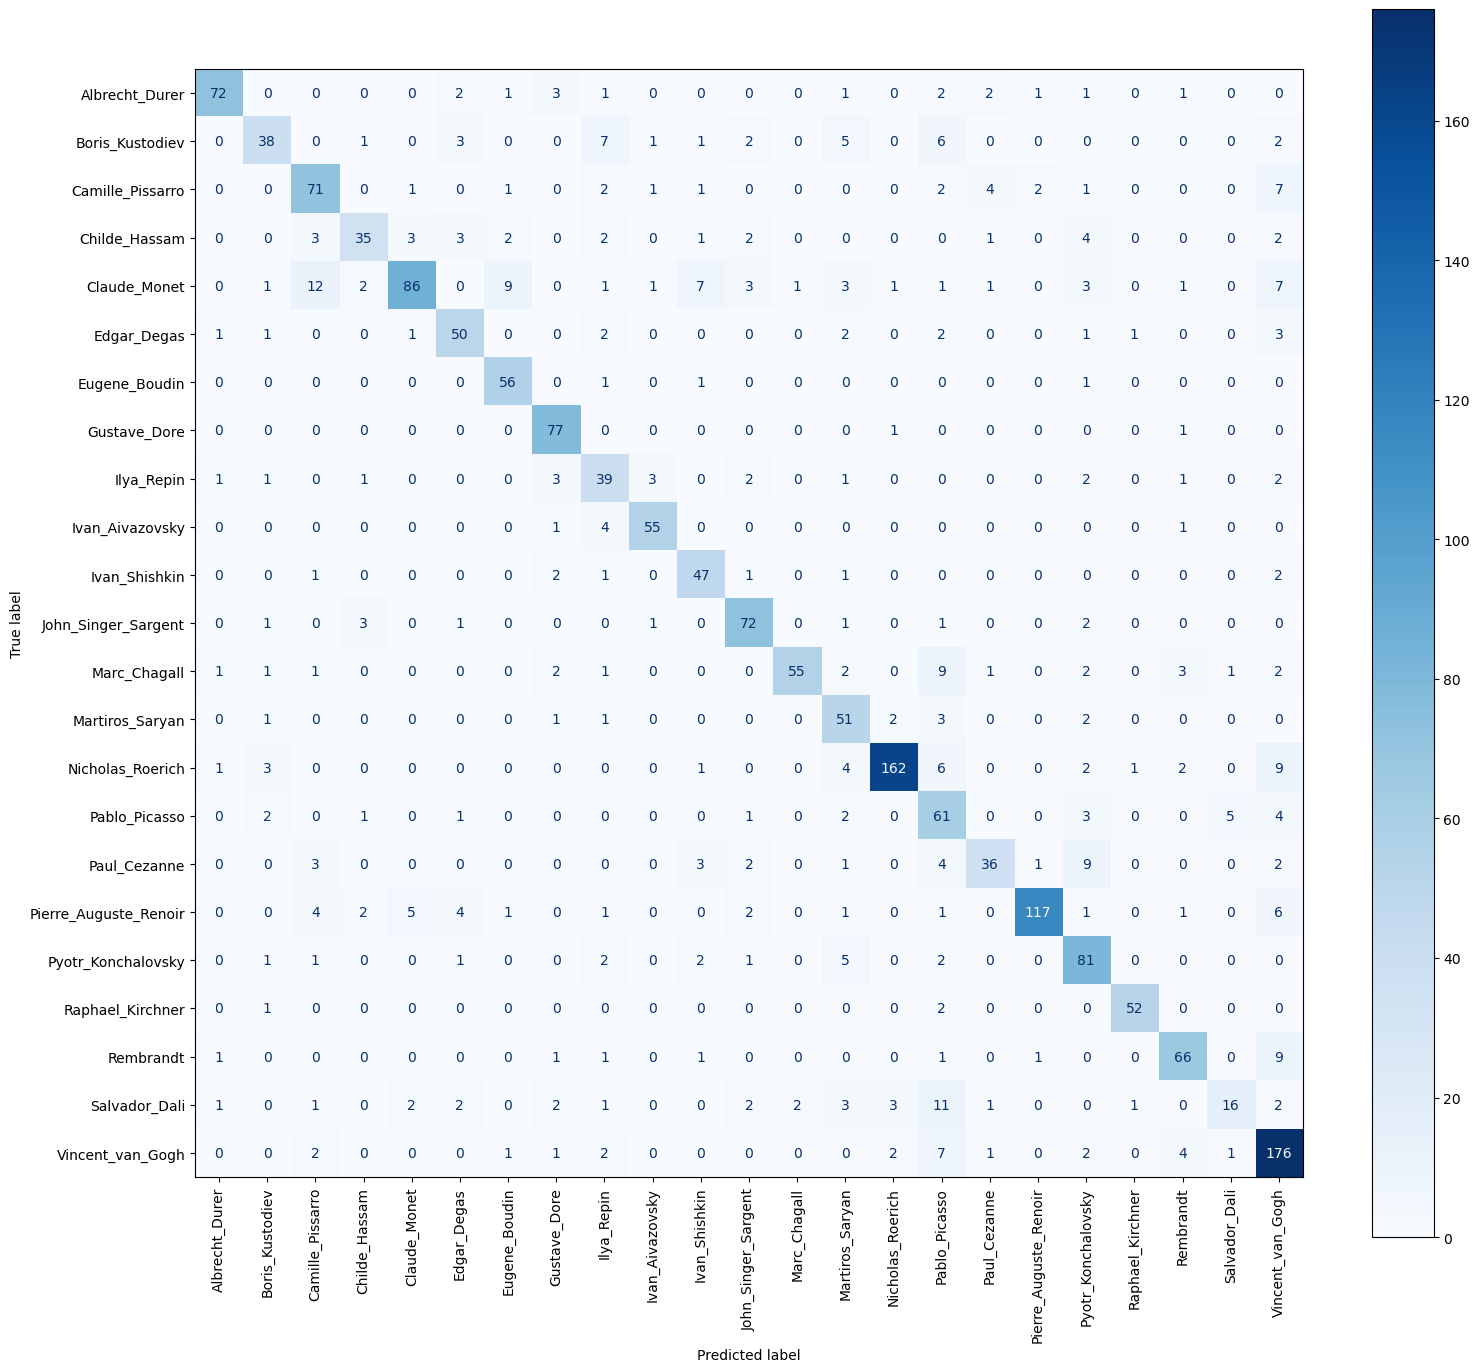


                    True class  as  Predicted class                 Count
------------------------------------------------------------------------------------------
                  Claude_Monet  as  Camille_Pissarro                12
                 Salvador_Dali  as  Pablo_Picasso                   11
                  Claude_Monet  as  Eugene_Boudin                   9
                  Marc_Chagall  as  Pablo_Picasso                   9
              Nicholas_Roerich  as  Vincent_van_Gogh                9
                  Paul_Cezanne  as  Pyotr_Konchalovsky              9
                     Rembrandt  as  Vincent_van_Gogh                9
               Boris_Kustodiev  as  Ilya_Repin                      7
              Camille_Pissarro  as  Vincent_van_Gogh                7
                  Claude_Monet  as  Ivan_Shishkin                   7


In [18]:
best_name = max(ensembles, key=lambda k: ensembles[k]["macro_f1"])
best     = ensembles[best_name]
print(f"Strongest ensemble: {best_name}")
print(f"  Top-1 {best['top1']:.4f} | Top-3 {best['top3']:.4f} | Top-5 {best['top5']:.4f}"
      f" | macro-F1 {best['macro_f1']:.4f} | weighted-F1 {best['weighted_f1']:.4f}")

cm = confusion_matrix(y_true, best["y_pred"])
fig, ax = plt.subplots(figsize=(16, 14))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES).plot(
    ax=ax, xticks_rotation=90, values_format="d", cmap="Blues",
)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "ensemble_confusion_matrix.png"), dpi=150, bbox_inches="tight")
plt.show()

cm_off = cm.astype(float).copy()
np.fill_diagonal(cm_off, 0)
print(f"\n{'True class':>30s}  as  {'Predicted class':<30s}  Count")
print("-" * 90)
top_conf = []
for _ in range(10):
    i, j = np.unravel_index(cm_off.argmax(), cm_off.shape)
    count = int(cm_off[i, j])
    if count == 0:
        break
    print(f"{CLASS_NAMES[i]:>30s}  as  {CLASS_NAMES[j]:<30s}  {count}")
    top_conf.append((CLASS_NAMES[i], CLASS_NAMES[j], count))
    cm_off[i, j] = 0

with open(os.path.join(OUT_DIR, "best_ensemble_summary.json"), "w") as f:
    json.dump({
        "name":        best_name,
        "top1":        best["top1"],
        "top3":        best["top3"],
        "top5":        best["top5"],
        "macro_f1":    best["macro_f1"],
        "weighted_f1": best["weighted_f1"],
        "top_confusions": top_conf,
    }, f, indent=2)


## 7. Per-class F1 of the strongest ensemble

Per-class precision/recall/F1 — identifies which classes drive most of the residual error. Saved as `ensemble_per_class_report.csv`.

In [19]:
report_str = classification_report(y_true, best["y_pred"], target_names=CLASS_NAMES, zero_division=0)
print(report_str)

report_dict = classification_report(y_true, best["y_pred"], target_names=CLASS_NAMES, zero_division=0, output_dict=True)
per_class = pd.DataFrame(report_dict).T.round(4)
per_class.to_csv(os.path.join(OUT_DIR, "ensemble_per_class_report.csv"))


                       precision    recall  f1-score   support

       Albrecht_Durer       0.92      0.83      0.87        87
      Boris_Kustodiev       0.75      0.58      0.65        66
     Camille_Pissarro       0.72      0.76      0.74        93
        Childe_Hassam       0.78      0.60      0.68        58
         Claude_Monet       0.88      0.61      0.72       140
          Edgar_Degas       0.75      0.78      0.76        64
        Eugene_Boudin       0.79      0.95      0.86        59
         Gustave_Dore       0.83      0.97      0.90        79
           Ilya_Repin       0.57      0.70      0.62        56
      Ivan_Aivazovsky       0.89      0.90      0.89        61
        Ivan_Shishkin       0.72      0.85      0.78        55
  John_Singer_Sargent       0.80      0.88      0.84        82
         Marc_Chagall       0.95      0.68      0.79        81
      Martiros_Saryan       0.61      0.84      0.71        61
     Nicholas_Roerich       0.95      0.85      0.90  

## 8. Agreement analysis

For every test image, count how many **distinct** classes the loaded models predict among themselves.
- The 1-unique row is the full-agreement rate — a ceiling on ensemble upside.
- Accuracy on the 2+ rows tells us how hard the disagreement images are.
- The `Any-correct` column is the oracle ceiling.

In [20]:
if len(loaded) >= 2:
    preds_per_model = np.stack([loaded[n]["y_pred"] for n in names], axis=0)
    agreement = (preds_per_model == preds_per_model[0]).all(axis=0)
    print(f"Full-agreement rate across {len(names)} models: {agreement.mean():.3f}")

    n_unique = np.array([len(np.unique(preds_per_model[:, i])) for i in range(preds_per_model.shape[1])])
    acc_per_model = np.mean(preds_per_model == y_true[None, :], axis=1)
    print("Individual test accuracies:")
    for n, a in zip(names, acc_per_model):
        print(f"  {n:40s} {a:.4f}")
    print()
    header = f"{'Unique predictions':<22s} {'Fraction':>10s} {'Ensemble-acc':>14s} {'Any-correct':>14s}"
    print(header)
    for k in sorted(np.unique(n_unique)):
        mask = n_unique == k
        frac = float(mask.mean())
        ens_correct = float((best["y_pred"][mask] == y_true[mask]).mean())
        any_correct = float((preds_per_model[:, mask] == y_true[mask][None, :]).any(axis=0).mean())
        print(f"  {k} unique{'':<13s} {frac:>9.4f} {ens_correct:>14.4f} {any_correct:>14.4f}")
else:
    print("Need at least 2 loaded models for agreement analysis.")


Full-agreement rate across 6 models: 0.164
Individual test accuracies:
  EfficientNetV2-B0 (phase 2)              0.7811
  MiniResNet (OOP)                         0.4833
  ResNet50V2 (phase 2)                     0.7186
  AlexNet-inspired                         0.4858
  Sequential baseline                      0.3433
  Sequential + RandAug                     0.3398

Unique predictions       Fraction   Ensemble-acc    Any-correct
  1 unique                 0.1644         0.9787         0.9787
  2 unique                 0.2809         0.8808         0.9324
  3 unique                 0.2779         0.7662         0.8687
  4 unique                 0.2099         0.6238         0.8333
  5 unique                 0.0600         0.4833         0.7000
  6 unique                 0.0070         0.5714         0.6429
